## Stellar-mass emulator (CAMELS SB35, L50n512)

Predict **log10 M★** for a halo from:
- its **halo mass** (log10 M200c at that snapshot),
- the **redshift** of the snapshot,
- its **formation times** `t_form_10/25/50/90`,
- the box's **cosmological + astrophysical parameters** (from the catalog headers).

Trained on the per-box catalogs from `camels_merger_history_parallel.py`. The train/test
split is **by box**, so the test score reflects generalization to parameter sets the
model never saw.

In [7]:
import glob
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import joblib
from tqdm import tqdm

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

OUT_DIR    = '/home/jovyan/home/camels_mass_history'
PARAM_FILE = ('/home/jovyan/Sims/IllustrisTNG/L50n512/SB35/'
              'CosmoAstroSeed_IllustrisTNG_L50n512_SB35.txt')
PERCENTS   = [10, 25, 50, 90]
MODEL_OUT  = '/home/jovyan/home/shmr_merger/mstar_emulator_SB35.joblib'

# cosmo + astro parameter columns to use as features (native param-file names, minus seed)
with open(PARAM_FILE) as fh:
    PARAM_KEYS = [c for c in fh.readline().lstrip('#').split()[1:] if c.lower() != 'seed']
print(f'{len(PARAM_KEYS)} parameter features:', PARAM_KEYS)

HALO_FEATS = ['logM200c', 'redshift'] + [f't_form_{p}' for p in PERCENTS]
FEATURES   = HALO_FEATS + PARAM_KEYS

35 parameter features: ['Omega0', 'sigma8', 'WindEnergyIn1e51erg', 'RadioFeedbackFactor', 'VariableWindVelFactor', 'RadioFeedbackReiorientationFactor', 'OmegaBaryon', 'HubbleParam', 'n_s', 'MaxSfrTimescale', 'FactorForSofterEQS', 'IMFslope', 'SNII_MinMass_Msun', 'ThermalWindFraction', 'VariableWindSpecMomentum', 'WindFreeTravelDensFac', 'MinWindVel', 'WindEnergyReductionFactor', 'WindEnergyReductionMetallicity', 'WindEnergyReductionExponent', 'WindDumpFactor', 'SeedBlackHoleMass', 'BlackHoleAccretionFactor', 'BlackHoleEddingtonFactor', 'BlackHoleFeedbackFactor', 'BlackHoleRadiativeEfficiency', 'QuasarThreshold', 'QuasarThresholdPower', 'UVBH0beta', 'UVBH0Deltaz', 'UVBHepbeta', 'UVBHepDeltaz', 'SNIa_Rate_Norm', 'SNIa_Rate_DTD_power', 'SofteningComovingType01']


### 1. Build the training table

Sample up to `max_rows_per_box` rows (across snapshots) from each box, attach that box's
parameters, and keep `log10 M★` as the target. Lower `max_rows_per_box` / raise `snap_step`
for a quick pass; raise `max_rows_per_box` for the final model.

In [2]:
def build_table(files, max_rows_per_box=2000, snap_step=1, seed=0):
    rng = np.random.default_rng(seed)
    blocks = []
    tcols = [f't_form_{p}' for p in PERCENTS]
    for bi, fn in enumerate(tqdm(files)):
        with h5py.File(fn, 'r') as f:
            try:
                par = np.array([float(f.attrs[k]) for k in PARAM_KEYS])
            except KeyError:
                continue                                  # header missing a param
            snaps = sorted(int(n.split('_')[1]) for n in f.keys())[::snap_step]
            rows = []
            for s in snaps:
                g = f[f'snap_{s:03d}']
                n = int(g.attrs['n_halos'])
                if n == 0:
                    continue
                z = float(g.attrs['redshift'])
                m200  = g['M200c_snap'][:]
                mstar = g['Mstar'][:]
                tf = np.column_stack([g[c][:] for c in tcols])
                rows.append(np.column_stack([m200, np.full(n, z), tf, mstar]))
            if not rows:
                continue
            arr = np.vstack(rows)                          # [m200, z, tf10..90, mstar]
            if len(arr) > max_rows_per_box:
                arr = arr[rng.choice(len(arr), max_rows_per_box, replace=False)]
            par_block = np.tile(par, (len(arr), 1))
            box_col = np.full((len(arr), 1), bi)
            # columns: m200, z, tf10..90, *params, box, mstar
            blocks.append(np.hstack([arr[:, :-1], par_block, box_col, arr[:, -1:]]))
    data = np.vstack(blocks)

    cols = (['M200c', 'redshift'] + tcols + PARAM_KEYS + ['box', 'Mstar'])
    df = pd.DataFrame(data, columns=cols)
    df['box'] = df['box'].astype(int)
    return df


files = sorted(glob.glob(f'{OUT_DIR}/*_dm_mass_history.hdf5'))
print(f'{len(files)} box files')
df = build_table(files, max_rows_per_box=2000, snap_step=1)
print('raw rows:', len(df))

1023 box files


100%|██████████| 1023/1023 [04:58<00:00,  3.42it/s]


raw rows: 2046000


In [5]:
# keep halos with stars and a real halo mass; build features + target
df = df[(df['Mstar'] > 0) & (df['M200c'] > 0)].copy()
df['logM200c'] = np.log10(df['M200c'])
df['logMstar'] = np.log10(df['Mstar'])

df = df.dropna(subset=FEATURES + ['logMstar'])
print(f'{len(df):,} training rows from {df["box"].nunique()} boxes')
df[FEATURES + ['logMstar']].describe().T[['mean', 'std', 'min', 'max']]

1,613,799 training rows from 1023 boxes


,mean,std,min,max
logM200c,11.146591,0.586048,8.315779e+00,15.108812
redshift,1.666022,1.607941,-2.220446e-16,14.951337
t_form_10,2.136852,1.265308,1.776234e-01,22.951039
t_form_25,3.343009,1.838836,2.320716e-01,22.951039
t_form_50,5.349998,2.702576,3.901060e-01,24.754040
t_form_90,9.724431,3.444663,5.567790e-01,25.542199
Omega0,0.296953,0.115463,1.001000e-01,0.499630
sigma8,0.804982,0.114980,6.000800e-01,0.999830
WindEnergyIn1e51erg,4.598666,3.558994,9.012100e-01,14.399000
RadioFeedbackFactor,1.353339,1.022868,2.502100e-01,3.995700


In [11]:
# save for later use 

df.to_parquet(f'{OUT_DIR}/emulator_training_table.parquet', engine='fastparquet')
#df = pd.read_parquet(f'{OUT_DIR}/emulator_training_table.parquet', engine='fastparquet')

### 2. Split by box (generalization to unseen parameter sets)

In [13]:
rng = np.random.default_rng(0)
all_boxes = df['box'].unique()
test_boxes = rng.choice(all_boxes, size=max(1, int(0.15 * len(all_boxes))), replace=False)
is_test = df['box'].isin(test_boxes)

X_tr, y_tr = df.loc[~is_test, FEATURES].to_numpy(), df.loc[~is_test, 'logMstar'].to_numpy()
X_te, y_te = df.loc[ is_test, FEATURES].to_numpy(), df.loc[ is_test, 'logMstar'].to_numpy()
print(f'train {X_tr.shape[0]:,} rows / {len(all_boxes)-len(test_boxes)} boxes   '
      f'test {X_te.shape[0]:,} rows / {len(test_boxes)} boxes')

train 1,372,909 rows / 870 boxes   test 240,890 rows / 153 boxes


### 3. Train the emulator

In [18]:
model = HistGradientBoostingRegressor(
    loss='squared_error',
    max_iter=600,
    learning_rate=0.05,
    max_leaf_nodes=63,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=25,
    random_state=0,
)
model.fit(X_tr, y_tr)
print('iterations:', model.n_iter_)

iterations: 600


### 4. Evaluate on held-out boxes

Held-out boxes:  R2 = 0.893   RMSE = 0.311 dex


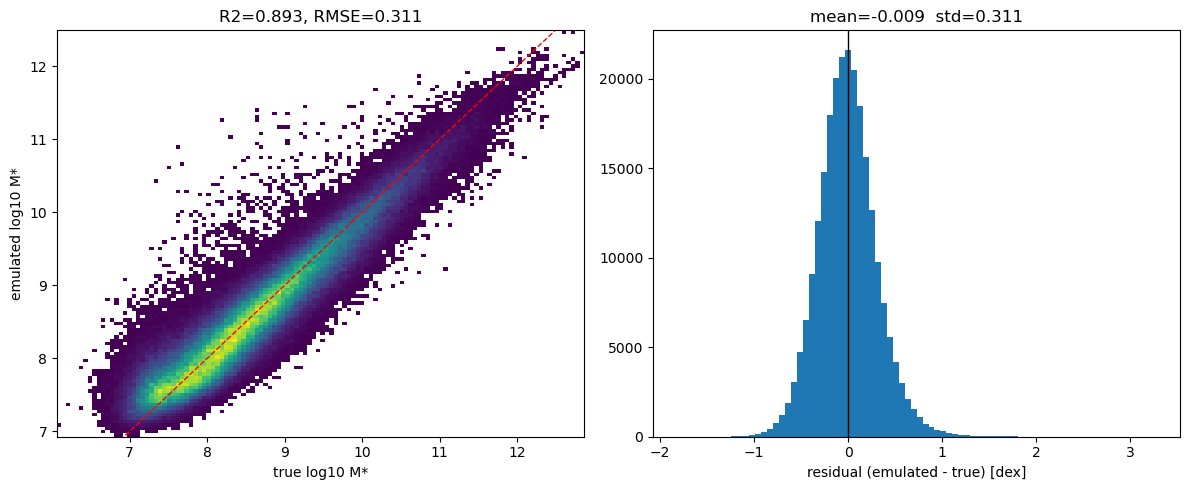

In [19]:
y_pred = model.predict(X_te)
r2   = r2_score(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
print(f'Held-out boxes:  R2 = {r2:.3f}   RMSE = {rmse:.3f} dex')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
h = ax[0].hist2d(y_te, y_pred, bins=120, cmin=1, cmap='viridis')
lim = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
ax[0].plot(lim, lim, 'r--', lw=1)
ax[0].set_xlabel('true log10 M*'); ax[0].set_ylabel('emulated log10 M*')
ax[0].set_title(f'R2={r2:.3f}, RMSE={rmse:.3f}')

res = y_pred - y_te
ax[1].hist(res, bins=80, color='C0')
ax[1].axvline(0, color='k', lw=1)
ax[1].set_xlabel('residual (emulated - true) [dex]')
ax[1].set_title(f'mean={res.mean():.3f}  std={res.std():.3f}')
plt.tight_layout(); plt.show()

### 5. Which inputs matter? (permutation importance on a test subsample)

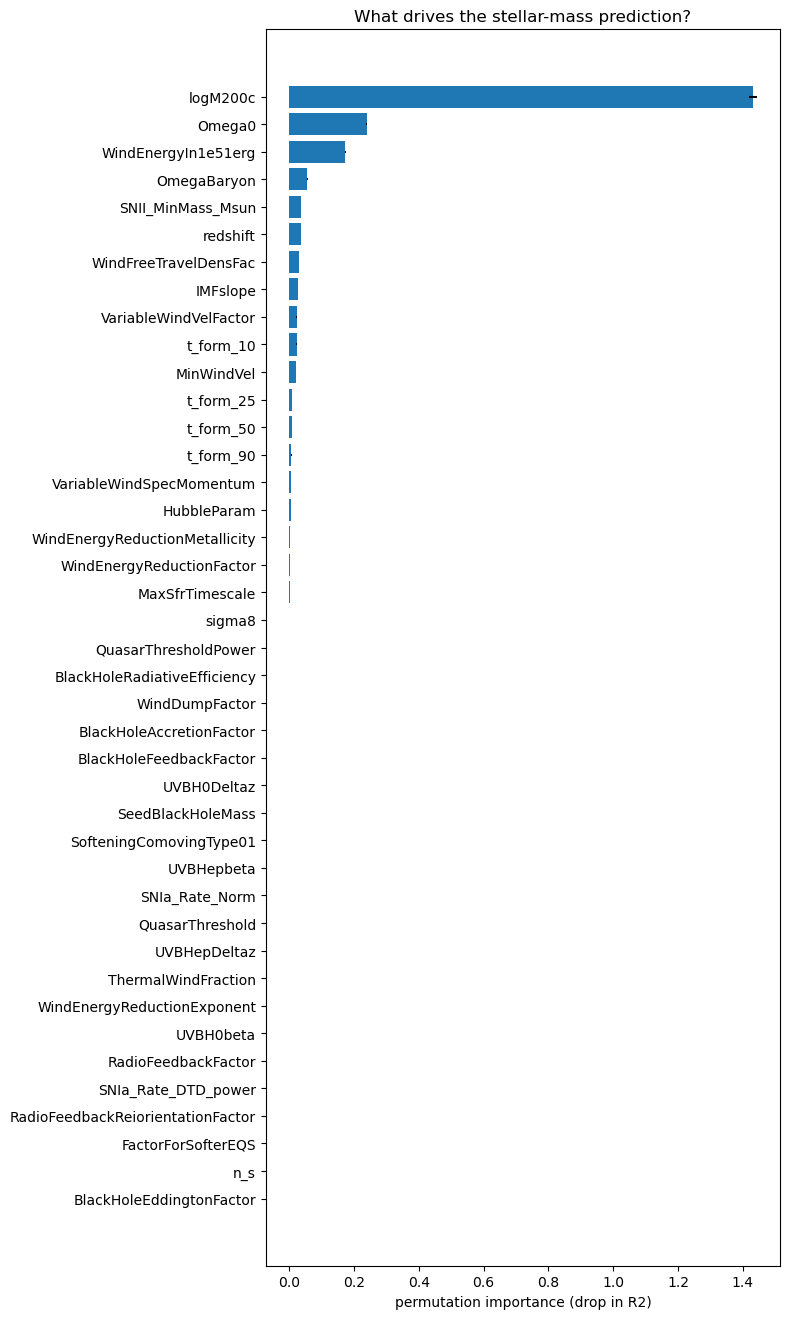

In [20]:
sub = np.random.default_rng(0).choice(len(X_te), size=min(20000, len(X_te)), replace=False)
imp = permutation_importance(model, X_te[sub], y_te[sub], n_repeats=5,
                             random_state=0, scoring='r2')
order = np.argsort(imp.importances_mean)

fig, ax = plt.subplots(figsize=(8, 0.3 * len(FEATURES) + 1))
ax.barh([FEATURES[i] for i in order], imp.importances_mean[order],
        xerr=imp.importances_std[order], color='C0')
ax.set_xlabel('permutation importance (drop in R2)')
ax.set_title('What drives the stellar-mass prediction?')
plt.tight_layout(); plt.show()

### 6. Save the emulator + a convenience predict function

In [ ]:
import os
os.makedirs(os.path.dirname(MODEL_OUT), exist_ok=True)
bundle = {'model': model, 'features': FEATURES, 'param_keys': PARAM_KEYS,
          'percents': PERCENTS, 'target': 'log10 Mstar [Msun]'}
joblib.dump(bundle, MODEL_OUT)
print('saved ->', MODEL_OUT)


def predict_mstar(logM200c, redshift, t_forms, params, bundle=bundle):
    """t_forms: dict or list aligned with PERCENTS; params: dict of param_keys.
    Returns predicted M* in Msun."""
    tf = [t_forms[p] for p in bundle['percents']] if isinstance(t_forms, dict) else list(t_forms)
    x = [logM200c, redshift] + tf + [params[k] for k in bundle['param_keys']]
    return 10.0 ** bundle['model'].predict(np.array([x], float))[0]

## Emulator for entire z = 0 LH Suite

In [21]:
# build table for specified snapshot, include all data, not a fraction of samples per snapshot 

def build_table_z0(files, snap=90):
    tcols = [f't_form_{p}' for p in PERCENTS]
    blocks = []
    for bi, fn in enumerate(tqdm(files)):
        with h5py.File(fn, 'r') as f:
            try:
                par = np.array([float(f.attrs[k]) for k in PARAM_KEYS])
            except KeyError:
                continue
            g = f[f'snap_{snap:03d}']
            n = int(g.attrs['n_halos'])
            if n == 0:
                continue
            m200  = g['M200c_snap'][:]
            mstar = g['Mstar'][:]
            tf = np.column_stack([g[c][:] for c in tcols])
            par_block = np.tile(par, (n, 1))
            box_col = np.full((n, 1), bi)
            blocks.append(np.hstack([m200[:, None], tf, par_block, box_col, mstar[:, None]]))
    cols = ['M200c'] + tcols + PARAM_KEYS + ['box', 'Mstar']
    df = pd.DataFrame(np.vstack(blocks), columns=cols)
    df['box'] = df['box'].astype(int)
    return df


files = sorted(glob.glob(f'{OUT_DIR}/*_dm_mass_history.hdf5'))
df = build_table_z0(files, snap=90)

# clean + features (no redshift now)
df = df[(df['Mstar'] > 0) & (df['M200c'] > 0)].copy()
df['logM200c'] = np.log10(df['M200c'])
df['logMstar'] = np.log10(df['Mstar'])
FEATURES = ['logM200c'] + [f't_form_{p}' for p in PERCENTS] + PARAM_KEYS
df = df.dropna(subset=FEATURES + ['logMstar'])
print(f'{len(df):,} z=0 halos from {df["box"].nunique()} boxes')

100%|██████████| 1023/1023 [00:04<00:00, 210.66it/s]


4,052,699 z=0 halos from 1023 boxes


In [67]:
# save for later use 

df.to_parquet(f'{OUT_DIR}/emulator_training_table_snapshot_90.parquet', engine='fastparquet')
#df = pd.read_parquet(f'{OUT_DIR}/emulator_training_table.parquet', engine='fastparquet')

In [54]:
# split by box, train (same as before)
rng = np.random.default_rng(0)
boxes = df['box'].unique()
test_boxes = rng.choice(boxes, size=int(0.15 * len(boxes)), replace=False)
is_test = df['box'].isin(test_boxes)
X_tr, y_tr = df.loc[~is_test, FEATURES].to_numpy(), df.loc[~is_test, 'logMstar'].to_numpy()
X_te, y_te = df.loc[ is_test, FEATURES].to_numpy(), df.loc[ is_test, 'logMstar'].to_numpy()

# first model run
# RESULT: Held-out boxes:  R2 = 0.878   RMSE = 0.344 dex
#model = HistGradientBoostingRegressor(
#    max_iter=600, learning_rate=0.05, max_leaf_nodes=63,
#    l2_regularization=1.0, early_stopping=True,
#    n_iter_no_change=25, random_state=0)

# second model run
# RESULT: Held-out boxes:  R2 = 0.880   RMSE = 0.341 dex
model = HistGradientBoostingRegressor(
    max_iter=1500, learning_rate=0.03, max_leaf_nodes=63,
    l2_regularization=1.0, early_stopping=True,
    n_iter_no_change=25, random_state=0)
model.fit(X_tr, y_tr)

y_pred = model.predict(X_te)
print(f'z=0 held-out: R2 = {r2_score(y_te, y_pred):.3f}  '
      f'RMSE = {np.sqrt(mean_squared_error(y_te, y_pred)):.3f} dex')

z=0 held-out: R2 = 0.880  RMSE = 0.341 dex


Held-out boxes:  R2 = 0.880   RMSE = 0.341 dex


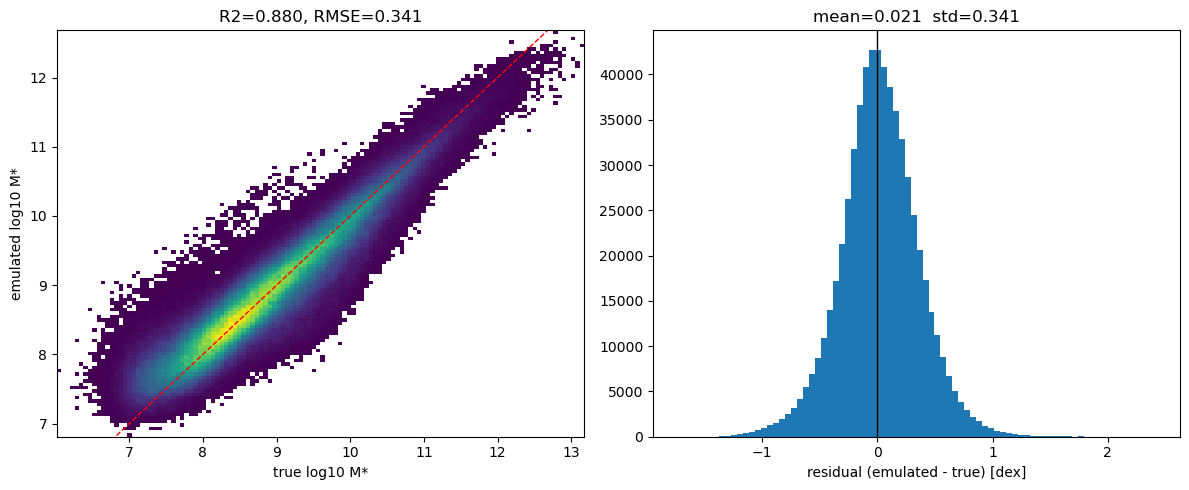

In [68]:
y_pred = model.predict(X_te)
r2   = r2_score(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
print(f'Held-out boxes:  R2 = {r2:.3f}   RMSE = {rmse:.3f} dex')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
h = ax[0].hist2d(y_te, y_pred, bins=120, cmin=1, cmap='viridis')
lim = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
ax[0].plot(lim, lim, 'r--', lw=1)
ax[0].set_xlabel('true log10 M*'); ax[0].set_ylabel('emulated log10 M*')
ax[0].set_title(f'R2={r2:.3f}, RMSE={rmse:.3f}')

res = y_pred - y_te
ax[1].hist(res, bins=80, color='C0')
ax[1].axvline(0, color='k', lw=1)
ax[1].set_xlabel('residual (emulated - true) [dex]')
ax[1].set_title(f'mean={res.mean():.3f}  std={res.std():.3f}')
plt.tight_layout(); plt.show()

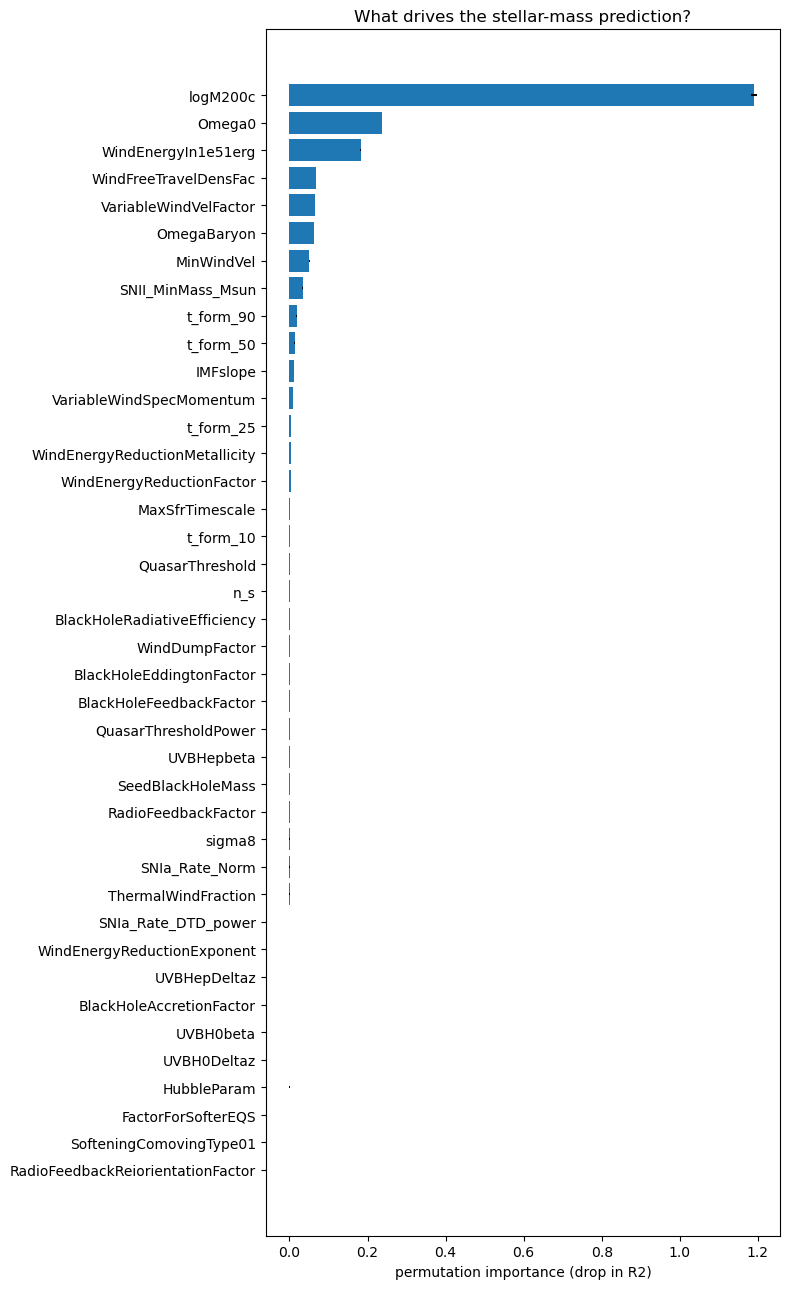

In [52]:
sub = np.random.default_rng(0).choice(len(X_te), size=min(20000, len(X_te)), replace=False)
imp = permutation_importance(model, X_te[sub], y_te[sub], n_repeats=5,
                             random_state=0, scoring='r2')
order = np.argsort(imp.importances_mean)

fig, ax = plt.subplots(figsize=(8, 0.3 * len(FEATURES) + 1))
ax.barh([FEATURES[i] for i in order], imp.importances_mean[order],
        xerr=imp.importances_std[order], color='C0')
ax.set_xlabel('permutation importance (drop in R2)')
ax.set_title('What drives the stellar-mass prediction?')
plt.tight_layout()
plt.savefig('feature_importance.pdf')
plt.show()

In [69]:
# save emulator 

import os
os.makedirs(os.path.dirname(MODEL_OUT), exist_ok=True)
bundle = {'model': model, 'features': FEATURES, 'param_keys': PARAM_KEYS,
          'percents': PERCENTS, 'target': 'log10 Mstar [Msun]'}
joblib.dump(bundle, MODEL_OUT)
print('saved ->', MODEL_OUT)


def predict_mstar(logM200c, redshift, t_forms, params, bundle=bundle):
    """t_forms: dict or list aligned with PERCENTS; params: dict of param_keys.
    Returns predicted M* in Msun."""
    tf = [t_forms[p] for p in bundle['percents']] if isinstance(t_forms, dict) else list(t_forms)
    x = [logM200c, redshift] + tf + [params[k] for k in bundle['param_keys']]
    return 10.0 ** bundle['model'].predict(np.array([x], float))[0]

saved -> /home/jovyan/home/shmr_merger/mstar_emulator_SB35.joblib


In [35]:
from scipy.stats import binned_statistic

# --- default assembly history: median t_form vs halo mass from the training data ---
_edges = np.linspace(df['logM200c'].min(), df['logM200c'].max(), 40)
tform_med = {}
for p in PERCENTS:
    med, e, _ = binned_statistic(df['logM200c'], df[f't_form_{p}'],
                                 statistic='median', bins=_edges)
    c = 0.5 * (e[:-1] + e[1:]); ok = np.isfinite(med)
    tform_med[p] = (c[ok], med[ok])

# baseline parameter vector = median across boxes (override what you care about)
base_params = {k: float(df[k].median()) for k in PARAM_KEYS}
def make_params(**overrides):
    p = dict(base_params); p.update(overrides); return p

def predict_shmr(params, logM=np.linspace(10.5, 14.0, 20), tforms=None):
    """params: dict of PARAM_KEYS. tforms: None -> use median t_form(M);
    or dict {10:..,25:..,50:..,90:..} to fix the history. Returns (logM, logMstar)."""
    X = []
    for lm in logM:
        tf = ([np.interp(lm, *tform_med[p]) for p in PERCENTS] if tforms is None
              else [tforms[p] for p in PERCENTS])
        X.append([lm] + tf + [params[k] for k in PARAM_KEYS])
    return logM, model.predict(np.array(X, float))

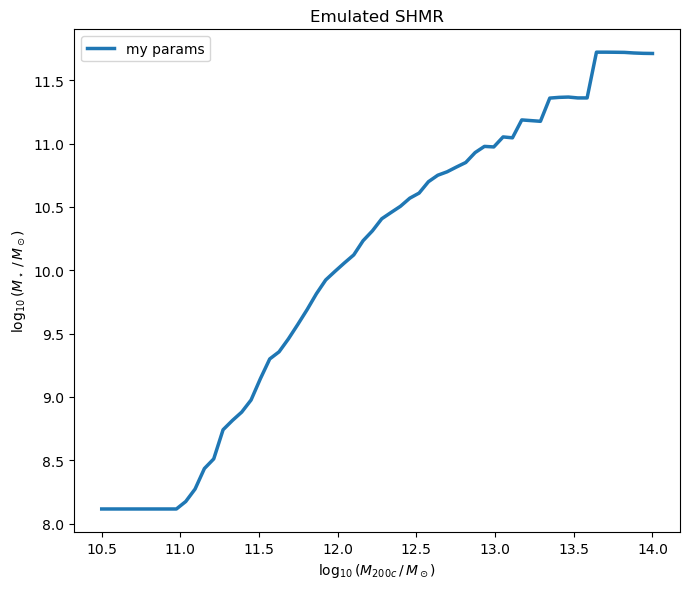

In [26]:
fig, ax = plt.subplots(figsize=(7, 6))

# your arbitrary parameter set:
p1 = make_params(Omega0=0.3, sigma8=0.8, OmegaBaryon=0.049, HubbleParam=0.6774)
lm, lms = predict_shmr(p1)
ax.plot(lm, lms, lw=2.5, label='my params')

ax.set_xlabel(r'$\log_{10}(M_{200c}\,/\,M_\odot)$')
ax.set_ylabel(r'$\log_{10}(M_\star\,/\,M_\odot)$')
ax.set_title('Emulated SHMR'); ax.legend()
plt.tight_layout(); plt.show()

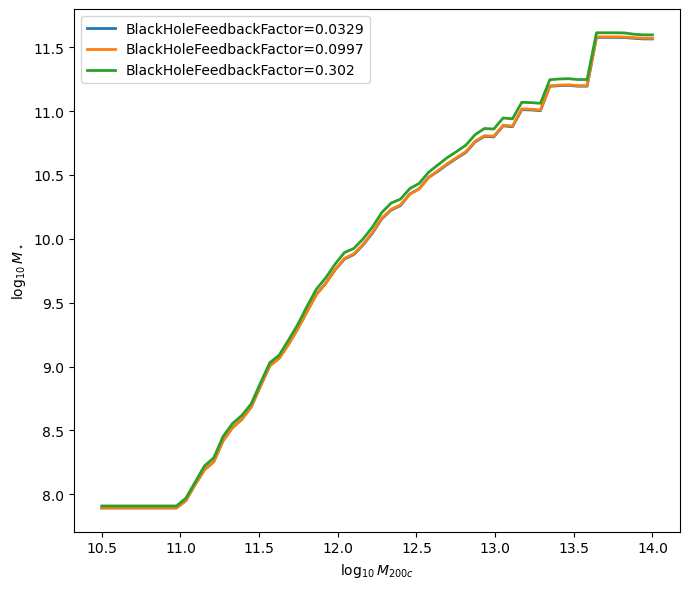

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))
key = 'BlackHoleFeedbackFactor'                 # any PARAM_KEYS entry
for val in np.percentile(df[key], [10, 50, 90]):
    lm, lms = predict_shmr(make_params(**{key: val}))
    ax.plot(lm, lms, lw=2, label=f'{key}={val:.3g}')
ax.set_xlabel(r'$\log_{10} M_{200c}$'); ax.set_ylabel(r'$\log_{10} M_\star$')
ax.legend(); plt.tight_layout(); plt.show()

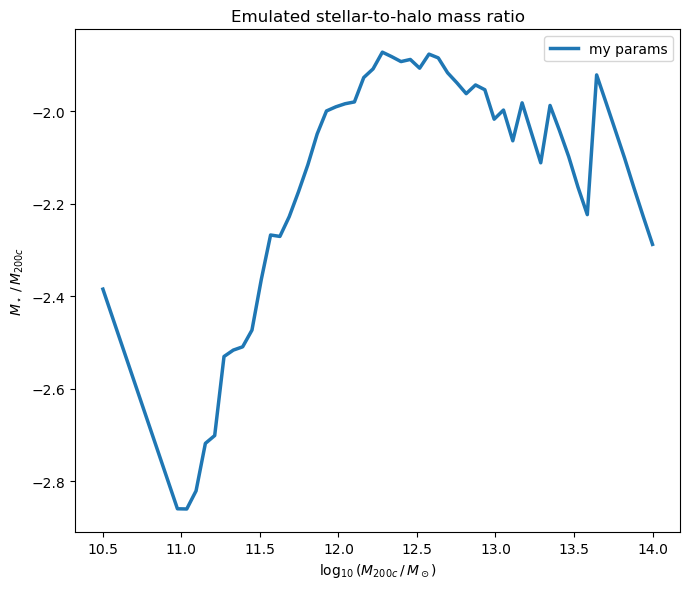

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))

p1 = make_params(Omega0=0.3, sigma8=0.8, OmegaBaryon=0.049, HubbleParam=0.6774)
lm, lms = predict_shmr(p1)

ratio = np.log10(10**lms / 10**lm)          # M*/M200c
ax.plot(lm, ratio, lw=2.5, label='my params')

ax.set_yscale('linear')
ax.set_xlabel(r'$\log_{10}(M_{200c}\,/\,M_\odot)$')
ax.set_ylabel(r'$M_\star\,/\,M_{200c}$')
ax.set_title('Emulated stellar-to-halo mass ratio')
ax.legend(); plt.tight_layout(); plt.show()

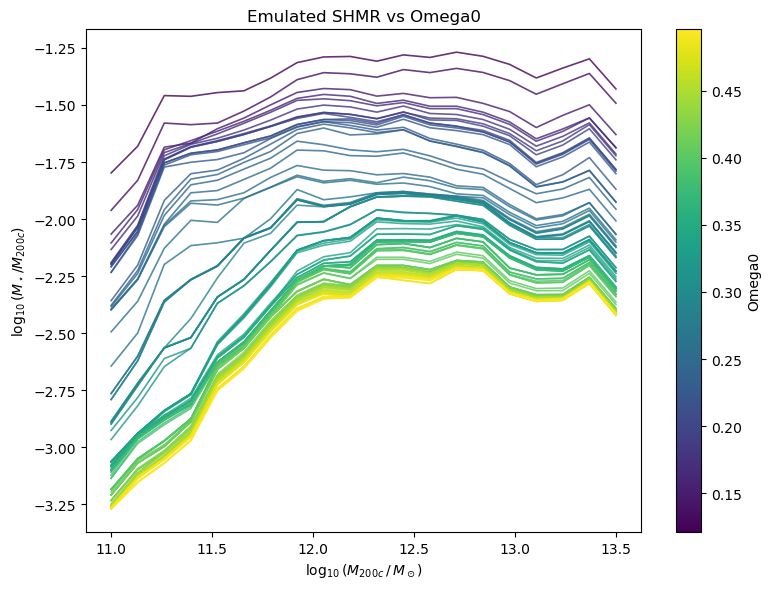

In [43]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

key = 'Omega0'
LO, HI = df['logM200c'].min(), 13.5
logM = np.linspace(LO, HI, 20)

vals = np.percentile(df[key], np.arange(1, 99, 1))
norm = Normalize(vals.min(), vals.max())
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(8, 6))
for val in vals:
    lm, lms = predict_shmr(make_params(**{key: val}), logM=logM)   # <-- vary the param
    ax.plot(lm, lms - lm, color=cmap(norm(val)), lw=1.2, alpha=0.8)

sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
fig.colorbar(sm, ax=ax, label=key)
ax.set_xlabel(r'$\log_{10}(M_{200c}\,/\,M_\odot)$')
ax.set_ylabel(r'$\log_{10}(M_\star / M_{200c})$')
ax.set_title(f'Emulated SHMR vs {key}')
plt.tight_layout(); plt.show()

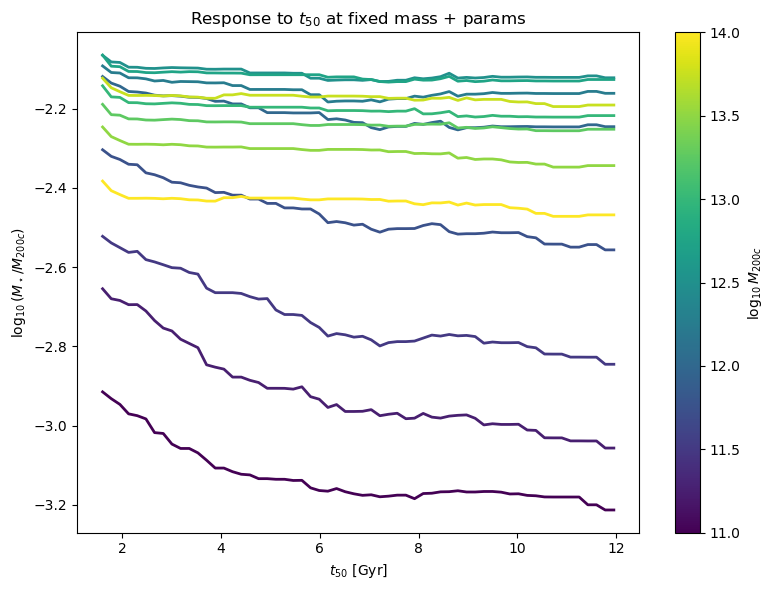

In [45]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

mh_grid = np.arange(11.0, 14.01, 0.25)        # halo masses to show
t50_grid = np.linspace(df['t_form_50'].quantile(0.02),
                       df['t_form_50'].quantile(0.98), 60)
base = make_params()

norm = Normalize(mh_grid.min(), mh_grid.max())
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(8, 6))
for lmh in mh_grid:
    tf_fixed = {p: float(np.interp(lmh, *tform_med[p])) for p in PERCENTS}
    preds = []
    for t50 in t50_grid:
        tf = dict(tf_fixed); tf[50] = t50
        x = [lmh] + [tf[p] for p in PERCENTS] + [base[k] for k in PARAM_KEYS]
        preds.append(model.predict(np.array([x], float))[0])
    preds = np.array(preds)
    ax.plot(t50_grid, preds - lmh, color=cmap(norm(lmh)), lw=2)   # log10(M*/M200c)

sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
fig.colorbar(sm, ax=ax, label=r'$\log_{10} M_{200c}$')
ax.set_xlabel(r'$t_{50}$ [Gyr]')
ax.set_ylabel(r'$\log_{10}(M_\star / M_{200c})$')
ax.set_title(r'Response to $t_{50}$ at fixed mass + params')
plt.tight_layout(); plt.show()

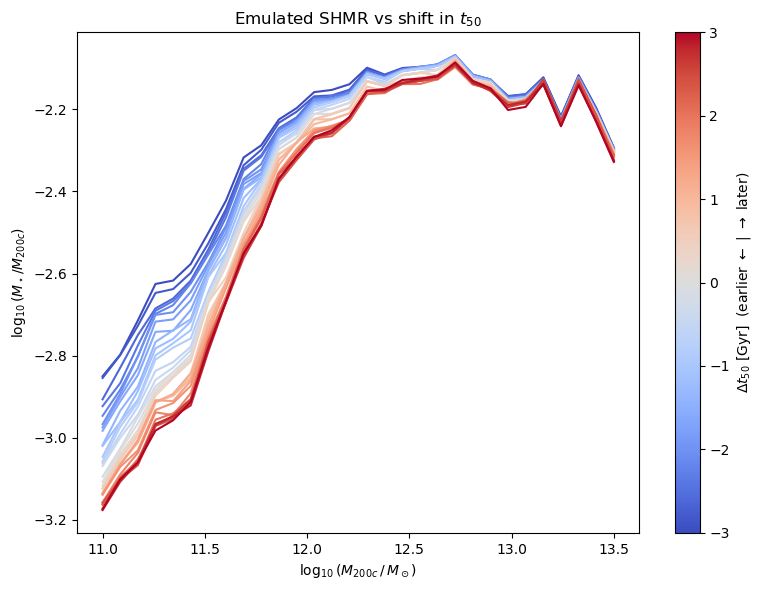

In [51]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

LO, HI = df['logM200c'].min(), 13.5
logM = np.linspace(LO, HI, 30)
base = make_params()
i50 = PERCENTS.index(50)                      # position of t_form_50 in the feature block

shifts = np.linspace(-3, 3, 31)               # Gyr added to the median t50(mass)
norm = Normalize(shifts.min(), shifts.max())
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 6))
for dt in shifts:
    X = []
    for lm in logM:
        tf = [np.interp(lm, *tform_med[p]) for p in PERCENTS]   # median history
        tf[i50] = tf[i50] + dt                                  # shift only t50
        X.append([lm] + tf + [base[k] for k in PARAM_KEYS])
    lms = model.predict(np.array(X, float))
    ax.plot(logM, lms - logM, color=cmap(norm(dt)), lw=1.5)

sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
fig.colorbar(sm, ax=ax, label=r'$\Delta t_{50}$ [Gyr]  (earlier $\leftarrow$ | $\rightarrow$ later)')
ax.set_xlabel(r'$\log_{10}(M_{200c}\,/\,M_\odot)$')
ax.set_ylabel(r'$\log_{10}(M_\star / M_{200c})$')
ax.set_title(r'Emulated SHMR vs shift in $t_{50}$')
plt.tight_layout(); 
plt.savefig('emulated_shmr_t50.pdf')
plt.show()

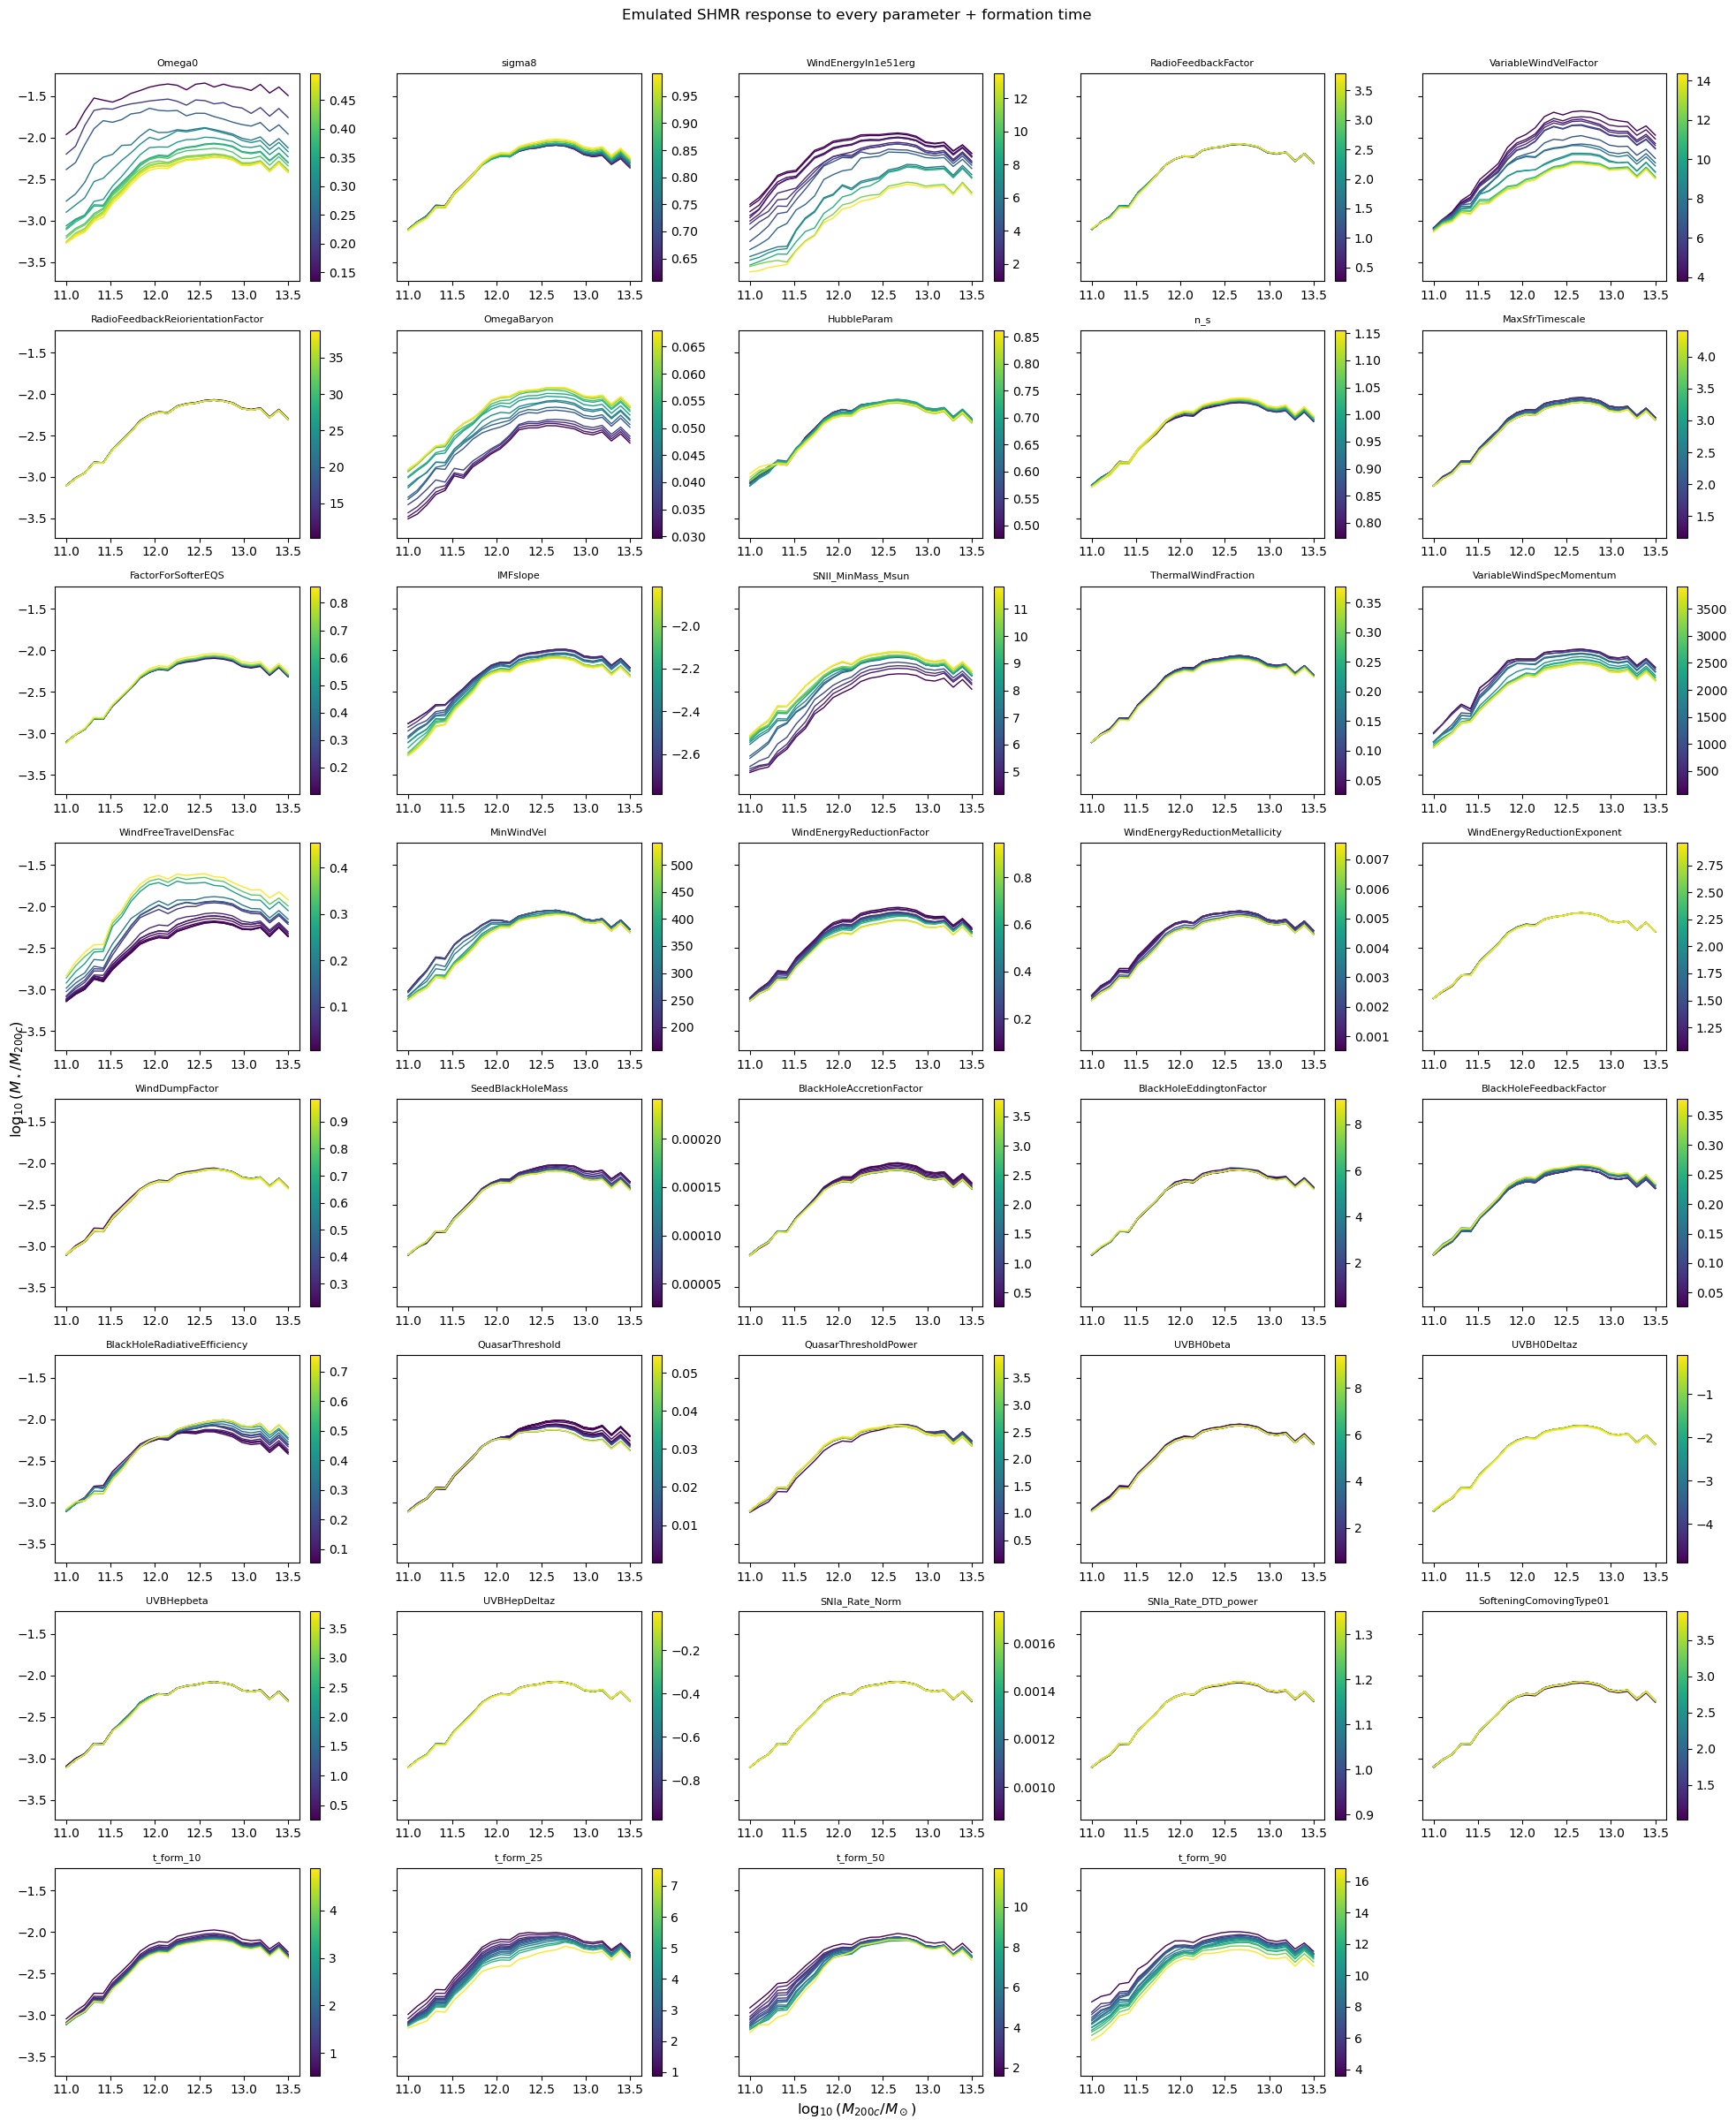

In [50]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

TFORM_KEYS = [f't_form_{p}' for p in PERCENTS]
sweep_keys = PARAM_KEYS + TFORM_KEYS           # everything in one grid
nvals = 15
LO, HI = df['logM200c'].min(), 13.5
logM = np.linspace(LO, HI, 25)
base = make_params()
cmap = plt.cm.viridis

def shmr_for(key, val):
    """Predict log10(M*) over logM. If key is a t_form, set that percentile to
    `val` at every mass (others stay at the median history); else vary the param."""
    X = []
    for lm in logM:
        tf = [np.interp(lm, *tform_med[p]) for p in PERCENTS]   # median history
        par = dict(base)
        if key in TFORM_KEYS:
            tf[PERCENTS.index(int(key.split('_')[-1]))] = val
        else:
            par[key] = val
        X.append([lm] + tf + [par[k] for k in PARAM_KEYS])
    return logM, model.predict(np.array(X, float))

ncol = 5
nrow = int(np.ceil(len(sweep_keys) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow), sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, key in zip(axes, sweep_keys):
    src = df[key]                              # sweep over the data range of this quantity
    vals = np.percentile(src, np.linspace(2, 98, nvals))
    norm = Normalize(vals.min(), vals.max())
    for val in vals:
        lm, lms = shmr_for(key, val)
        ax.plot(lm, lms - lm, color=cmap(norm(val)), lw=1)
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(key, fontsize=8)

for ax in axes[len(sweep_keys):]:
    ax.axis('off')

fig.supxlabel(r'$\log_{10}(M_{200c}/M_\odot)$')
fig.supylabel(r'$\log_{10}(M_\star/M_{200c})$')
fig.suptitle('Emulated SHMR response to every parameter + formation time', y=1.005)
plt.tight_layout()
plt.savefig('emulated_shmr.pdf')
plt.show()

In [56]:
# from max's comment:

tcols = [f't_form_{p}' for p in PERCENTS]
feat_with    = FEATURES
feat_without = [f for f in FEATURES if f not in tcols]

def train_eval(feats):
    m = HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05, max_leaf_nodes=63,
            l2_regularization=1.0, early_stopping=True, n_iter_no_change=25, random_state=0)
    m.fit(df.loc[~is_test, feats].to_numpy(), y_tr)
    yp = m.predict(df.loc[is_test, feats].to_numpy())
    return yp

yp_with    = train_eval(feat_with)
yp_without = train_eval(feat_without)

for name, yp in [('with t_form', yp_with), ('no t_form', yp_without)]:
    print(f'{name:12s} R2={r2_score(y_te, yp):.4f}  RMSE={np.sqrt(mean_squared_error(y_te, yp)):.4f} dex')

# the important comparison: residual scatter AT FIXED halo mass
te = df[is_test].copy()
te['res_with'], te['res_without'] = y_te - yp_with, y_te - yp_without
bins = np.arange(11, 14.01, 0.25)
te['mbin'] = pd.cut(te['logM200c'], bins)
print(te.groupby('mbin').apply(lambda d: pd.Series({
    'rmse_with':    d['res_with'].std(),
    'rmse_without': d['res_without'].std(),
    'N': len(d)})))

with t_form  R2=0.8782  RMSE=0.3443 dex
no t_form    R2=0.8467  RMSE=0.3862 dex
               rmse_with  rmse_without         N
mbin                                            
(11.0, 11.25]   0.366924      0.408447  227925.0
(11.25, 11.5]   0.358015      0.406359  152353.0
(11.5, 11.75]   0.331967      0.376677   96734.0
(11.75, 12.0]   0.305906      0.342064   59045.0
(12.0, 12.25]   0.289388      0.323951   35740.0
(12.25, 12.5]   0.278704      0.309839   21072.0
(12.5, 12.75]   0.270915      0.298668   12808.0
(12.75, 13.0]   0.247774      0.282767    7687.0
(13.0, 13.25]   0.247119      0.283497    4507.0
(13.25, 13.5]   0.242320      0.284539    2616.0
(13.5, 13.75]   0.277953      0.299509    1517.0
(13.75, 14.0]   0.226207      0.246679     868.0


/tmp/ipykernel_6944/3257371378.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(te.groupby('mbin').apply(lambda d: pd.Series({
/tmp/ipykernel_6944/3257371378.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(te.groupby('mbin').apply(lambda d: pd.Series({


/tmp/ipykernel_6944/3918337839.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summ = te.groupby('mbin').apply(lambda d: pd.Series({
/tmp/ipykernel_6944/3918337839.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summ = te.groupby('mbin').apply(lambda d: pd.Series({


               std_true  std_pred  std_resid         N
mbin                                                  
(11.0, 11.25]  0.718891  0.550192   0.366924  227925.0
(11.25, 11.5]  0.773741  0.599207   0.358015  152353.0
(11.5, 11.75]  0.770405  0.599137   0.331967   96734.0
(11.75, 12.0]  0.721399  0.563033   0.305906   59045.0
(12.0, 12.25]  0.675586  0.519856   0.289388   35740.0
(12.25, 12.5]  0.631957  0.487446   0.278704   21072.0
(12.5, 12.75]  0.595053  0.453517   0.270915   12808.0
(12.75, 13.0]  0.557599  0.415777   0.247774    7687.0
(13.0, 13.25]  0.543441  0.396130   0.247119    4507.0
(13.25, 13.5]  0.533908  0.392193   0.242320    2616.0
(13.5, 13.75]  0.500394  0.402185   0.277953    1517.0
(13.75, 14.0]  0.462646  0.320806   0.226207     868.0


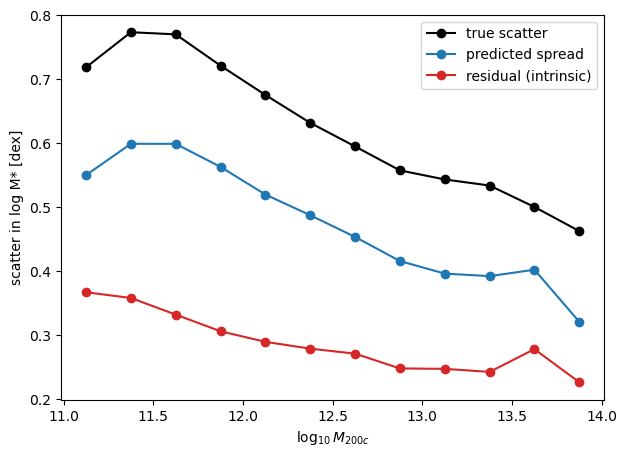

In [64]:
te['pred'] = yp_with
summ = te.groupby('mbin').apply(lambda d: pd.Series({
    'std_true':  d['logMstar'].std(),     # total scatter at this mass
    'std_pred':  d['pred'].std(),         # scatter the model attributes to features
    'std_resid': (d['logMstar']-d['pred']).std(),  # unexplained (intrinsic + error)
    'N': len(d)}))
print(summ)

fig, ax = plt.subplots(figsize=(7,5))
c = [b.mid for b in summ.index]
ax.plot(c, summ['std_true'],  'k-o', label='true scatter')
ax.plot(c, summ['std_pred'],  'C0-o', label='predicted spread')
ax.plot(c, summ['std_resid'], 'C3-o', label='residual (intrinsic)')
ax.set_xlabel(r'$\log_{10}M_{200c}$'); ax.set_ylabel('scatter in log M* [dex]')
ax.legend(); plt.show()

In [58]:
qmods = {}
for q in [0.16, 0.50, 0.84]:
    m = HistGradientBoostingRegressor(loss='quantile', quantile=q, max_iter=600,
            learning_rate=0.05, max_leaf_nodes=63, early_stopping=True, random_state=0)
    m.fit(X_tr, y_tr)
    qmods[q] = m.predict(X_te)

lo, hi = qmods[0.16], qmods[0.84]
cov = np.mean((y_te >= lo) & (y_te <= hi))
print(f'empirical 68% coverage = {cov:.3f}   (calibrated ≈ 0.68)')
print(f'median predicted interval width = {np.median(hi-lo):.3f} dex')

# coverage per mass bin (is it overconfident only at some masses?)
te['lo'], te['hi'] = lo, hi
print(te.groupby('mbin').apply(lambda d: np.mean((d['logMstar']>=d['lo'])&(d['logMstar']<=d['hi']))))

empirical 68% coverage = 0.451   (calibrated ≈ 0.68)
median predicted interval width = 0.388 dex
mbin
(11.0, 11.25]    0.516569
(11.25, 11.5]    0.457746
(11.5, 11.75]    0.413453
(11.75, 12.0]    0.380252
(12.0, 12.25]    0.347398
(12.25, 12.5]    0.328683
(12.5, 12.75]    0.342130
(12.75, 13.0]    0.359178
(13.0, 13.25]    0.387397
(13.25, 13.5]    0.430046
(13.5, 13.75]    0.490442
(13.75, 14.0]    0.661290
dtype: float64


/tmp/ipykernel_6944/1232861571.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(te.groupby('mbin').apply(lambda d: np.mean((d['logMstar']>=d['lo'])&(d['logMstar']<=d['hi']))))
/tmp/ipykernel_6944/1232861571.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(te.groupby('mbin').apply(lambda d: np.mean((d['logMstar']>=d['lo'])&(d['logMstar']<=d['hi']))))
